# Tutorials_ST_SM_downstream

In [1]:
import os
os.chdir("/public/home/off_liukunpeng/project/11_cluster_problem")
import sys
sys.path.append("/public/home/off_liukunpeng/project/11_cluster_problem/AgaeSMO/")
import AgaeSMO as AgaeSMO

In [2]:
import scanpy as sc
from matplotlib.patches import Circle
import matplotlib.pyplot as plt
from matplotlib_venn import venn3,venn2

In [3]:
adata=sc.read_h5ad("AgaeSMO/result/V11L12_109_A1.h5ad")

In [21]:
ms_A1=sc.read_h5ad('data/sma/V11L12-109_A1/ms.h5ad')

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when 

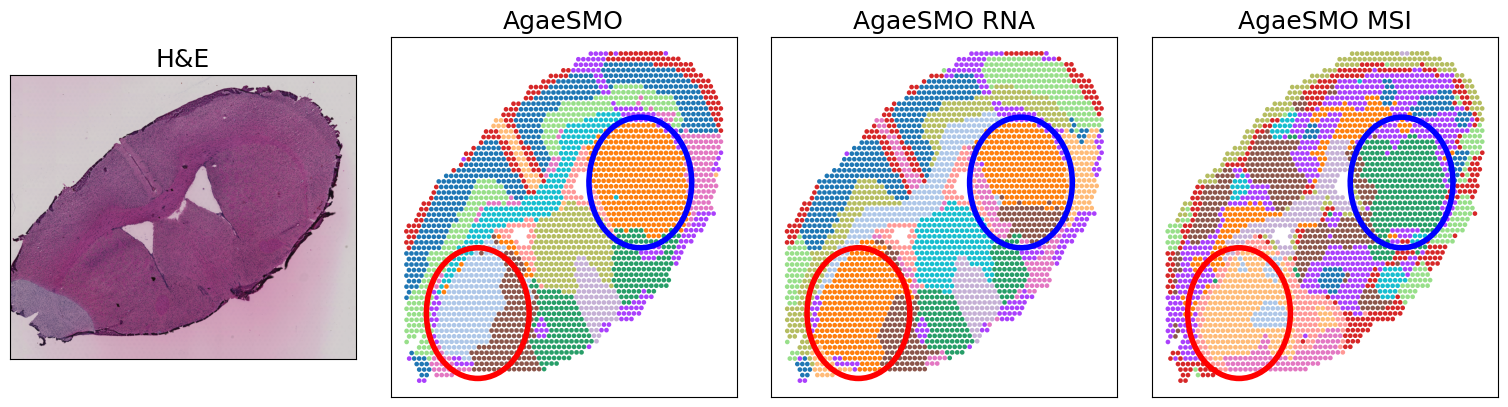

In [18]:
import matplotlib.pyplot as plt
fig,axs=plt.subplots(1,4,figsize=(16,4))
s_1=45

sc.pl.embedding(adata, basis='spatial', color="AgaeSMO", ax=axs[1] , title='AgaeSMO', s=s_1, show=False)
sc.pl.embedding(adata, basis='spatial', color="RNA", ax=axs[2] , title='AgaeSMO RNA', s=s_1, show=False)
sc.pl.embedding(adata, basis='spatial', color="MSI", ax=axs[3] , title='AgaeSMO MSI', s=s_1, show=False)
sc.pl.spatial(adata,img_key="hires", color=None,ax=axs[0],basis='spatial',title="H&E",show=False,legend_fontsize=1,legend_loc="none")

plt.subplots_adjust(left=0.02, bottom=0.05, right=0.95, top=0.95, wspace=0.1, hspace=0.1)
# axs[1,0].invert_yaxis()
# c1=Circle((600, 600), radius=250, edgecolor='r', facecolor='none', linewidth=4)
# c2=Circle((1300, 1200), radius=250, edgecolor='b', facecolor='none', linewidth=4)
# axs[1,0].add_patch(c1)
# axs[1,0].add_patch(c2)
# deepst__
# spaGCN__
# STAGATE_
# STMGraph
# AgaeSMO___
axs[0].invert_yaxis()
for i in range(4):
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    axs[i].set_title(axs[i].title.get_text(), fontsize=18)
    axs[i].legend().set_visible(False)
for i in range(3):
    axs[i].set_xlabel("")
    axs[i].set_ylabel("")
    axs[i].set_title(axs[i].title.get_text(), fontsize=18)
    axs[i].legend().set_visible(False)
for i in axs:
    circle1_1 = Circle((13000, 16000), radius=6000, edgecolor='r', facecolor='none', linewidth=4)
    circle1_2 = Circle((32000, 28000), radius=6000, edgecolor='b', facecolor='none', linewidth=4)
        
    i.add_patch(circle1_1)
    i.add_patch(circle1_2)
# axs[1,3].set_xlabel("")
# axs[1,3].set_ylabel("")
# axs[1,3].set_title(axs[1,3].title.get_text(), fontsize=18)
# axs[1,3].legend().set_visible(False)


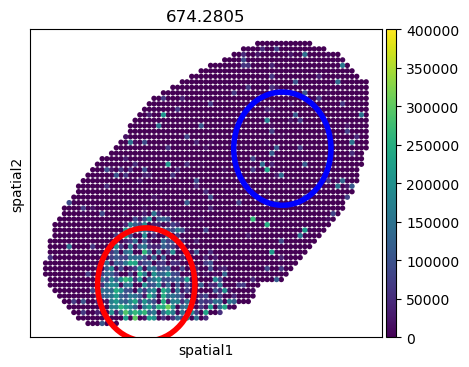

In [23]:
fig,axs=plt.subplots(1,figsize=(5,4))
sc.pl.embedding(ms_A1,  color=["674.2805"],ax=axs,basis='spatial',size=60,show=False,vmax=400000,legend_fontsize=1,legend_loc="none")
c1=Circle((600, 600), radius=250, edgecolor='r', facecolor='none', linewidth=4)
c2=Circle((1300, 1200), radius=250, edgecolor='b', facecolor='none', linewidth=4)
axs.add_patch(c1)
axs.add_patch(c2)

In [24]:
import seaborn as sns
def plot_weight_value(alpha, label, modality1='mRNA', modality2='protein',show=True):
  """\
  Plotting weight values
  
  """  
  import pandas as pd  
  
  df = pd.DataFrame(columns=[modality1, modality2, 'label'])  
  df[modality1], df[modality2] = alpha[:, 0], alpha[:, 1]
  df['label'] = label
  df = df.set_index('label').stack().reset_index()
  df.columns = ['label', 'Modality', 'Weight value']
  return df
  ax = sns.violinplot(data=df, y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
  ax.set_title(modality1 + ' vs ' + modality2) 

  plt.tight_layout(w_pad=0.05)
  if show:
    plt.show() 

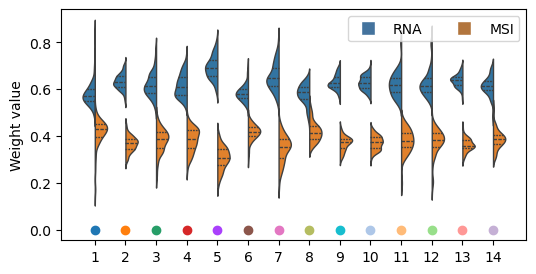

In [26]:
from matplotlib.lines import Line2D
fig,ax=plt.subplots(1,figsize=(6,3))

titles=[
"V11L12-109 A1",
"V11L12-109 B1",
"V11L12-109 C1",
]


for n,i in enumerate(set(adata.obs["AgaeSMO"])):
    alpha=adata.obsm["alpha"][adata.obs["AgaeSMO"]==i,:]
    
    df=plot_weight_value(alpha,"AgaeSMO",modality1='mRNA', modality2='MSI')
    sns.violinplot(data=df,ax=ax,x=n+1,y='Weight value', hue="Modality",
                split=True, inner="quart", linewidth=1)
    
    ax.scatter(n,0,c=adata.uns["AgaeSMO_colors"][n])
ax.legend().set_visible(False)
#     ax[j].set_title(titles[j])
#     legend = ax[j].legend()
#     legend.set_visible(False)
#     # break
legend_elements = [
    Line2D([0], [0], marker='s', color='w', label='RNA',       markerfacecolor="#44739d", markersize=10),
    Line2D([0], [0], marker='s', color='w', label='MSI',       markerfacecolor="#b2753d", markersize=10),
]
ax.legend(handles=legend_elements, ncol=2,loc= 'upper right' ,fontsize=10)


/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  row_ax = sns.violinplot(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  row_ax = sns.violinplot(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/plotting/_stacked_violin.py:461: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  row_ax = sns.violinplot(
/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/pytho

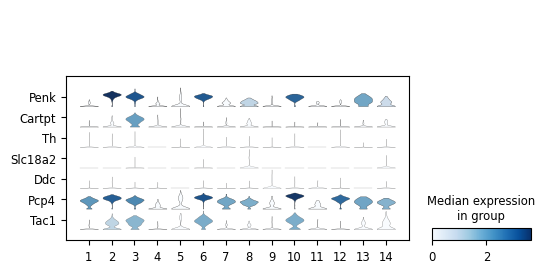

In [32]:
fig,ax=plt.subplots(1,figsize=(6,3))
masker=['Penk',"Cartpt","Th","Slc18a2","Ddc","Pcp4","Tac1"]
adata.obs['AgaeSMO'] = adata.obs['AgaeSMO'].astype(str)
sc.pl.stacked_violin(adata,masker,groupby='AgaeSMO',ax=ax,swap_axes=True)

/public/home/off_liukunpeng/software/anaconda3/envs/pytorch_1/lib/python3.8/site-packages/scanpy/tools/_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


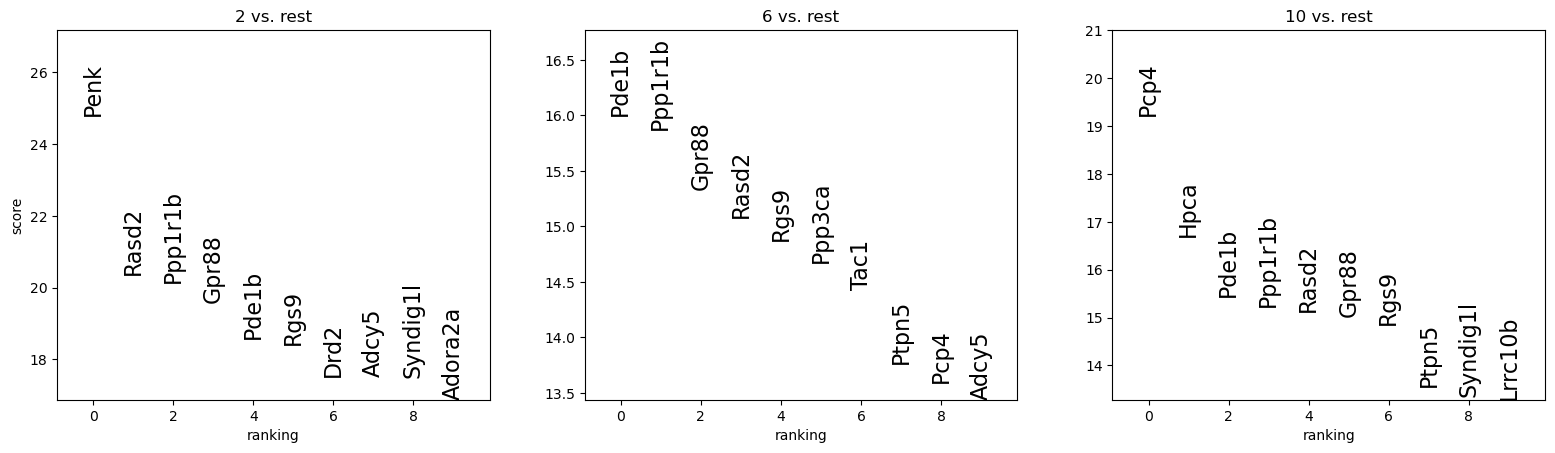

In [28]:
adata=adata
adata = adata[:, ~adata.var_names.str.startswith('mt-')]
sc.tl.rank_genes_groups(adata, "AgaeSMO", method="wilcoxon")
# sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)
# sc.pl.rank_genes_groups(adata, n_genes=25,groups="2",ax=ax[0,1],sharey=False,show=False)
# sc.pl.rank_genes_groups(adata, n_genes=25,groups=["2"],sharey=False)
sc.pl.rank_genes_groups(adata, n_genes=10,groups=["2","6","10"],sharey=False,show=False,fontsize=16)

In [29]:
rank_genes_1 = \
sc.get.rank_genes_groups_df(adata,group="2")["names"][0:10].tolist()+ \
sc.get.rank_genes_groups_df(adata,group="6")["names"][0:10].tolist()+ \
sc.get.rank_genes_groups_df(adata,group="10")["names"][0:10].tolist()
rank_genes_1 = list(set(rank_genes_1))

In [30]:
cluster_2=set(sc.get.rank_genes_groups_df(adata,group="2")["names"][0:10].tolist())
cluster_6=set(sc.get.rank_genes_groups_df(adata,group="6")["names"][0:10].tolist())
cluster_10=set(sc.get.rank_genes_groups_df(adata,group="10")["names"][0:10].tolist())

Text(0.5, 1.0, 'Cluster 2,6,10 vs other')

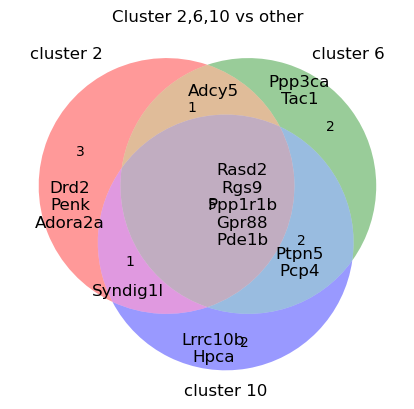

In [31]:
venn3([cluster_2,cluster_6,cluster_10],("cluster 2","cluster 6","cluster 10"))
plt.text(-0.5, 0, '\n'.join(map(str, cluster_2 - cluster_6 - cluster_10)), fontsize=12, ha='center', va='center')
plt.text(0.3, 0.4, '\n'.join(map(str, cluster_6 - cluster_2 - cluster_10)), fontsize=12, ha='center', va='center')
plt.text(-0, -0.5, '\n'.join(map(str, cluster_10 - cluster_6 - cluster_2)), fontsize=12, ha='center', va='center')
plt.text(0.3, -0.2, '\n'.join(map(str, cluster_10 & cluster_6 - cluster_2)), fontsize=12, ha='center', va='center')
plt.text(0, 0.4, '\n'.join(map(str, cluster_6 & cluster_2 - cluster_10)), fontsize=12, ha='center', va='center')
plt.text(-0.3, -0.3, '\n'.join(map(str, cluster_2 & cluster_10 - cluster_6)), fontsize=12, ha='center', va='center')
plt.text(0.1, 0, '\n'.join(map(str, cluster_2 & cluster_10 & cluster_6)), fontsize=12, ha='center', va='center')
plt.title('Cluster 2,6,10 vs other', fontsize=12)

In [33]:
marker={"2":cluster_2,
       "6":cluster_6,
       "10":cluster_10}

{'mainplot_ax': <Axes: >,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

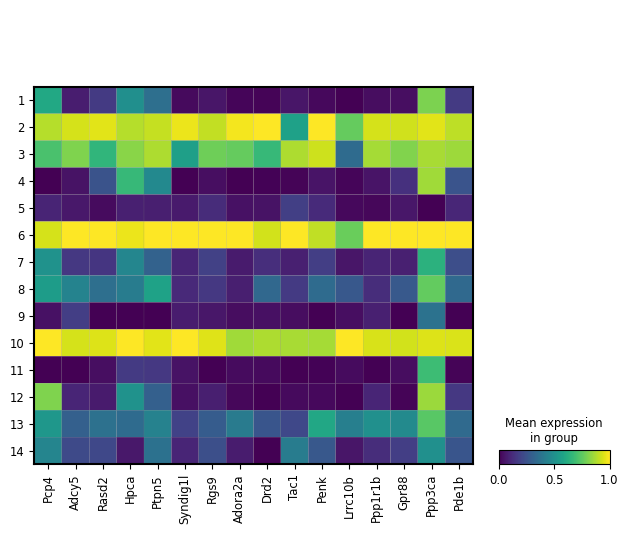

In [34]:
sc.pl.matrixplot(adata, rank_genes_1, groupby='AgaeSMO', use_raw=False, log=True, standard_scale='var', cmap='viridis',show=False)


In [68]:
(cluster_6|cluster_10)-cluster_2

{'Hpca', 'Lrrc10b', 'Pcp4', 'Ppp3ca', 'Ptpn5', 'Tac1'}

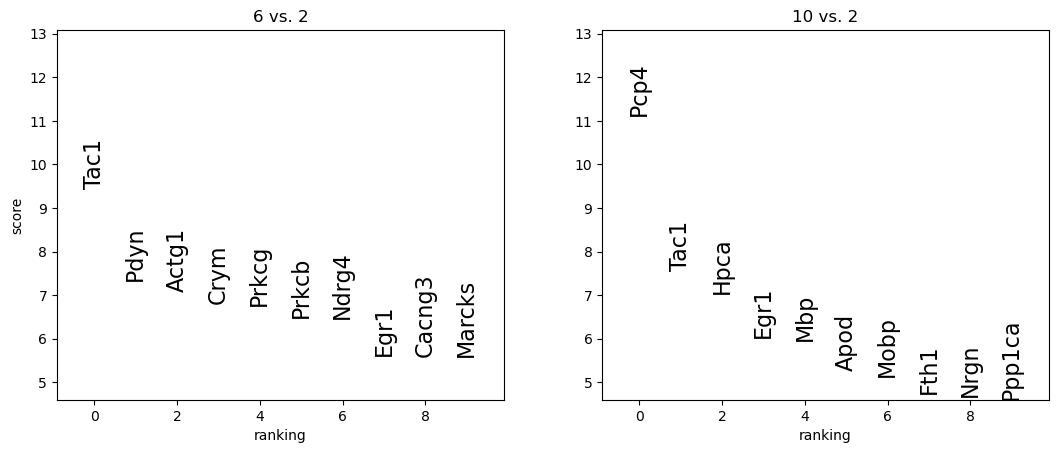

In [35]:
sc.tl.rank_genes_groups(adata, 'AgaeSMO',  reference="2", method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=['6',"10"],n_genes=10,show=False,fontsize=16)
# plt.savefig("plot/fig3_2610_internal_deg.png",dpi=600)
# sc.pl.rank_genes_groups(adata, groups=["10"],show=False,ax=ax[4], n_genes=25)
gene_2_6=sc.get.rank_genes_groups_df(adata,group="6")["names"][0:10].tolist()
gene_2_10=sc.get.rank_genes_groups_df(adata,group="10")["names"][0:10].tolist()

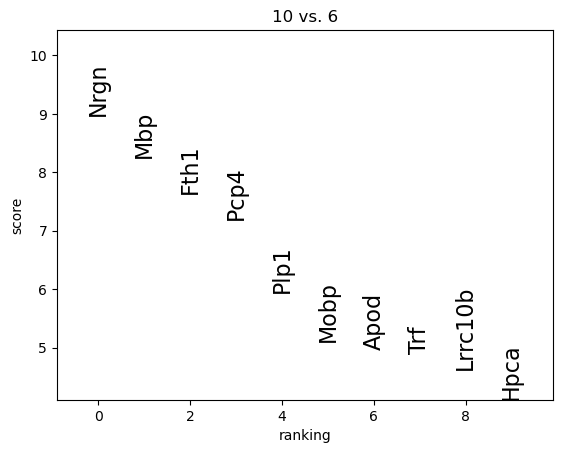

In [36]:
sc.tl.rank_genes_groups(adata, 'AgaeSMO',  reference="6", method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=["10"],n_genes=10,show=False,fontsize=16)
# plt.savefig("plot/fig3_610_internal_deg.png",dpi=600)
gene_10_6=sc.get.rank_genes_groups_df(adata,group="10")["names"][0:10].tolist()

In [37]:
gene_2_6

['Tac1',
 'Pdyn',
 'Actg1',
 'Crym',
 'Prkcg',
 'Prkcb',
 'Ndrg4',
 'Egr1',
 'Cacng3',
 'Marcks']

In [39]:
rank_genes_2 = gene_2_6+gene_2_10+gene_10_6
rank_genes_2=list(set(rank_genes_2))

{'mainplot_ax': <Axes: >,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

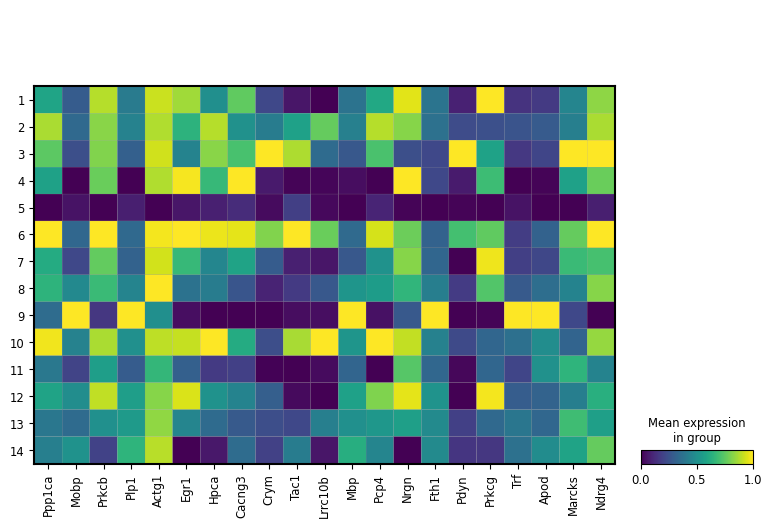

In [40]:
sc.pl.matrixplot(adata, rank_genes_2, groupby='AgaeSMO', use_raw=False, log=True, standard_scale='var', cmap='viridis',show=False)
# plt.savefig("plot/fig3_610_internal_deg_matrix_plot.png",dpi=600)

Text(0, 0, 'Lrrc10b\nPcp4\nTac1\nHpca')

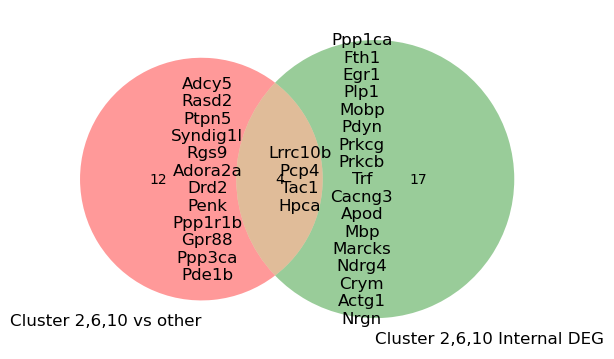

In [41]:
venn2([set(rank_genes_1),set(rank_genes_2)],("Cluster 2,6,10 vs other","Cluster 2,6,10 Internal DEG"))
plt.text(-0.3, 0, '\n'.join(map(str, set(rank_genes_1) - set(rank_genes_2))), fontsize=12, ha='center', va='center')
plt.text(0.2, 0, '\n'.join(map(str, set(rank_genes_2) - set(rank_genes_1))), fontsize=12, ha='center', va='center')
plt.text(-0, 0, '\n'.join(map(str, set(rank_genes_1) & set(rank_genes_2))), fontsize=12, ha='center', va='center')


In [43]:
seris=[]
for i in adata.obs["AgaeSMO"]:
    seris.append(i in ["2","6","10"])
# seris=pd.

<Figure size 640x480 with 0 Axes>

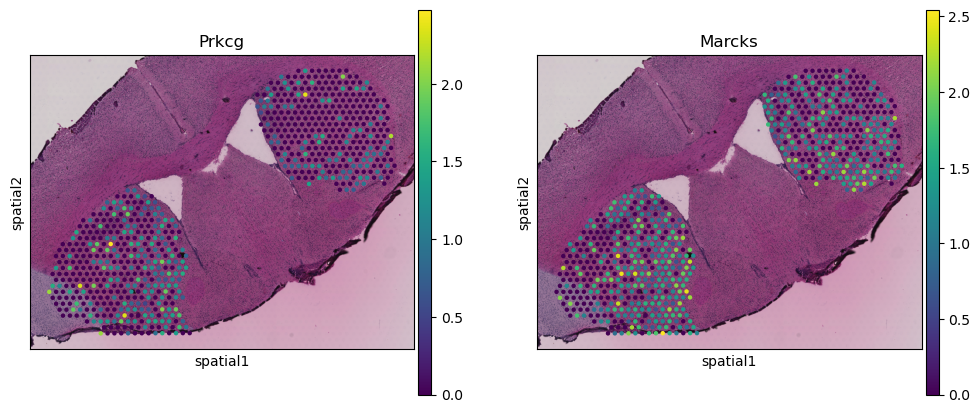

In [44]:
plt.clf()
fig,axs=plt.subplots(1,2,figsize=(12,5))
sc.pl.spatial(adata[seris,:],color="Prkcg",ax=axs[0],show=False)
sc.pl.spatial(adata[seris,:],color="Marcks",ax=axs[1],show=False)

axs[0].invert_yaxis()
axs[1].invert_yaxis()


<Figure size 640x480 with 0 Axes>

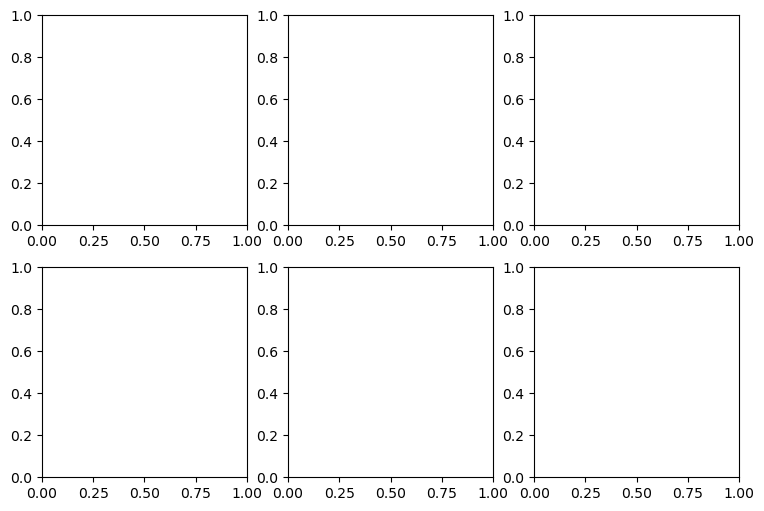

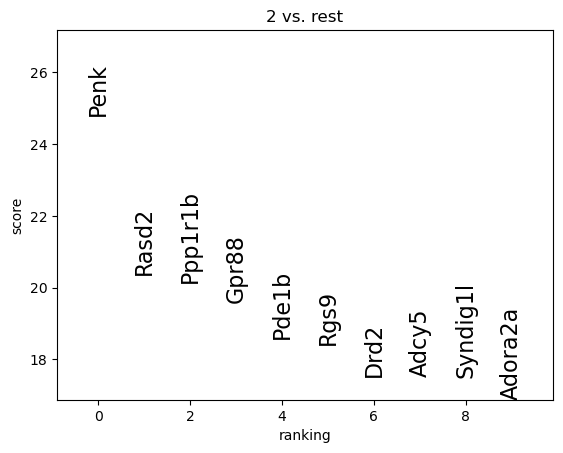

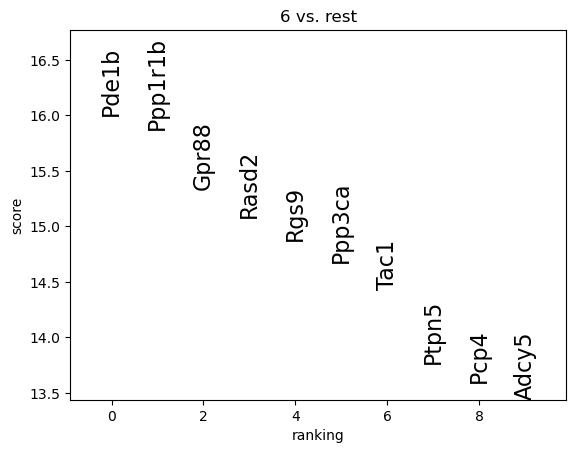

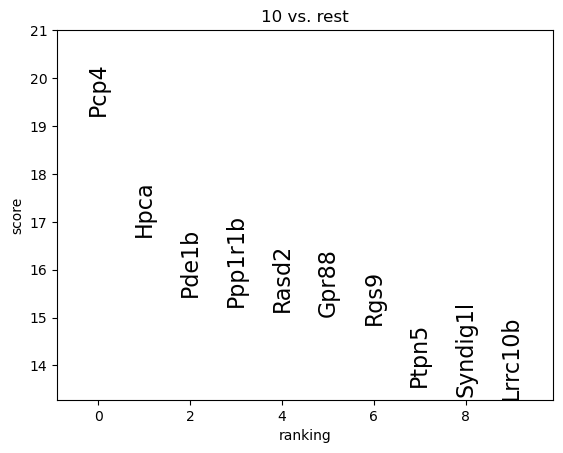

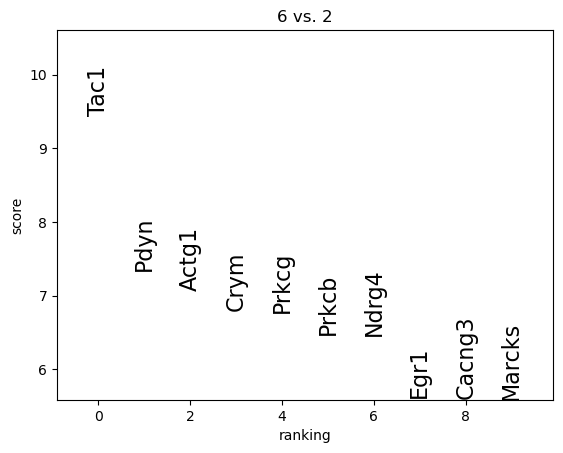

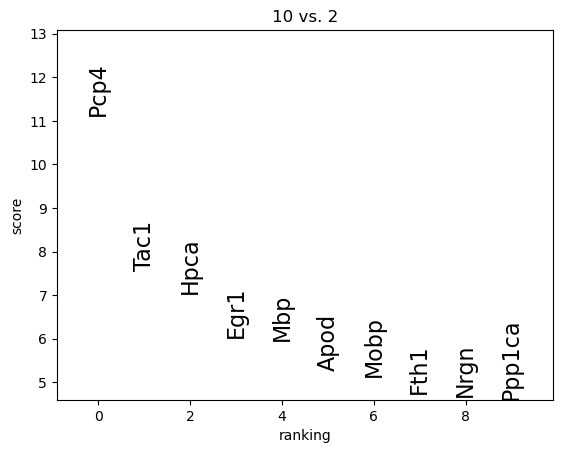

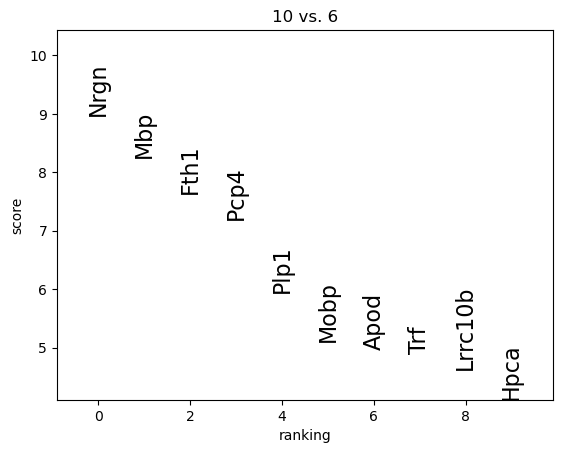

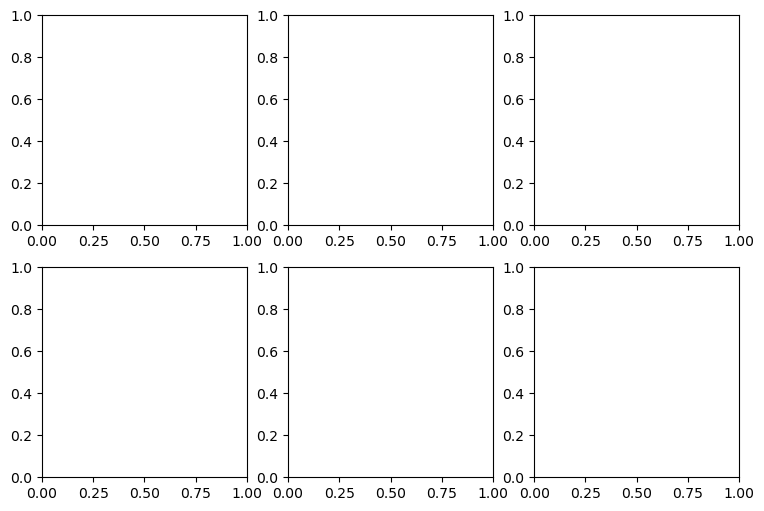

In [45]:
plt.clf()
fig,axs=plt.subplots(2,3,figsize=(9,6))

sc.tl.rank_genes_groups(adata, "AgaeSMO", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=10,ax=axs[0,0],groups=["2"],sharey=False,fontsize=16)
sc.pl.rank_genes_groups(adata, n_genes=10,ax=axs[0,1],groups=["6"],sharey=False,fontsize=16)
sc.pl.rank_genes_groups(adata, n_genes=10,ax=axs[0,2],groups=["10"],sharey=False,fontsize=16)

sc.tl.rank_genes_groups(adata, 'AgaeSMO',  reference="2", method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=["6"],n_genes=10,ax=axs[1,0],fontsize=16)
sc.pl.rank_genes_groups(adata, groups=["10"],n_genes=10,ax=axs[1,1],fontsize=16)

sc.tl.rank_genes_groups(adata, 'AgaeSMO',  reference="6", method='wilcoxon')
sc.pl.rank_genes_groups(adata, groups=["10"],n_genes=10,ax=axs[1,2],fontsize=16)
fig
# fig.savefig("plot/s10.png",dpi=600)